In [1]:
import pandas as pd                        
import numpy as np                         
import matplotlib.pyplot as plt             
import seaborn as sns

In [2]:
df=pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print("Column names:")
print(df.columns.tolist())
print()

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']



In [4]:
print("\nDataFrame Info:")
df.info()
print()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12 

In [5]:
print("\nSummary Statistics for Categorical Columns:")
display(df.describe(include='object'))


Summary Statistics for Categorical Columns:


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print()

Missing values per column:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                         

<Axes: >

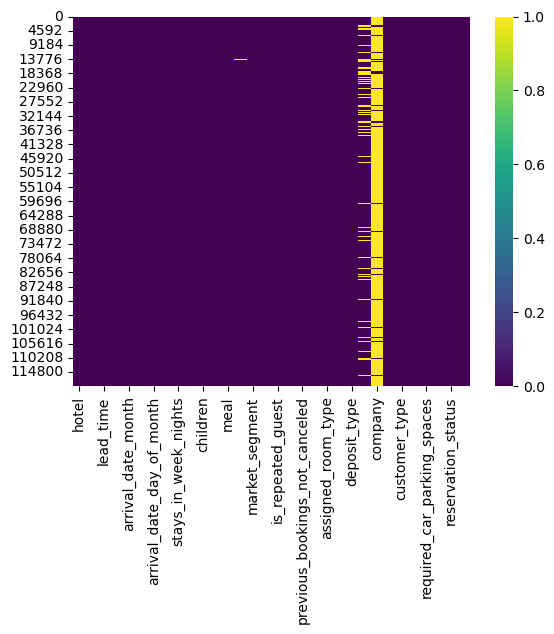

In [7]:
sns.heatmap(df.isnull(),cmap = 'viridis')

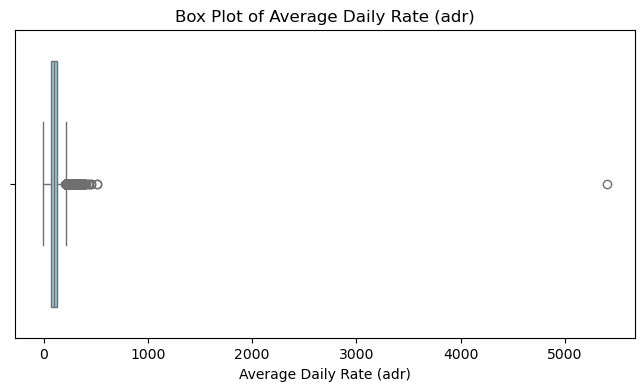

In [8]:
# Outlier detection for 'adr' (Average Daily Rate)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['adr'], color='skyblue')
plt.title('Box Plot of Average Daily Rate (adr)')
plt.xlabel('Average Daily Rate (adr)')
plt.show()

In [9]:
outlier_threshold = 5000
df = df[df['adr'] < outlier_threshold]
print(f"Data shape after removing adr outliers (adr < {outlier_threshold}): {df.shape}")


Data shape after removing adr outliers (adr < 5000): (119389, 32)


In [10]:
cols_to_drop = ['agent', 'company']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['agent', 'company']


In [11]:
df.dropna(inplace=True)
print(f"Data shape after dropping NA: {df.shape}")

Data shape after dropping NA: (118897, 30)


In [12]:
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
duplicate_rows

Number of duplicate rows: 31984


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,A,1,No Deposit,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,E,0,No Deposit,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,D,0,No Deposit,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,A,0,No Deposit,0,Transient,109.80,0,3,Check-Out,2015-07-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119349,City Hotel,0,186,2017,August,35,31,0,3,2,...,D,0,No Deposit,0,Transient,126.00,0,2,Check-Out,2017-09-03
119352,City Hotel,0,63,2017,August,35,31,0,3,3,...,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119353,City Hotel,0,63,2017,August,35,31,0,3,3,...,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03
119354,City Hotel,0,63,2017,August,35,31,0,3,3,...,D,0,No Deposit,0,Transient-Party,195.33,0,2,Check-Out,2017-09-03


In [13]:
df.drop_duplicates(inplace=True)
print(f"Data shape after removing duplicates: {df.shape}")

Data shape after removing duplicates: (86913, 30)


In [14]:
print("\nSummary statistics for numerical columns:")
display(df.describe())


Summary statistics for numerical columns:


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000,86913.000000
mean,0.275931,80.203261,2016.211844,26.841853,15.818347,1.007559,2.628974,1.878603,0.139254,0.010815,0.039246,0.030237,0.176763,0.271904,0.753731,106.519911,0.083474,0.699550
std,0.446985,86.103261,0.685992,13.654110,8.834535,1.028821,2.043864,0.625884,0.456850,0.113511,0.194181,0.369631,1.718149,0.728177,10.043367,51.944108,0.280441,0.831881
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,12.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000
50%,0.000000,50.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.410000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.100000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000


In [15]:
# Calculate the average lead time for each hotel type
avg_lead_time_by_hotel = df.groupby('hotel')['lead_time'].mean()

# Display the result
print("Average Lead Time by Hotel Type:")
print(avg_lead_time_by_hotel)

Average Lead Time by Hotel Type:
hotel
City Hotel      77.691122
Resort Hotel    84.206714
Name: lead_time, dtype: float64


In [16]:
def get_season(month):
    if month in ['December', 'January', 'February']:
        return 'Winter'
    elif month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['arrival_date_month'].apply(get_season)

In [17]:
season_total = df['season'].value_counts()
print(season_total)

season
Summer    29001
Spring    23666
Fall      18490
Winter    15756
Name: count, dtype: int64


In [18]:
season_hotel = df.groupby(['season', 'hotel']).size().unstack()
print("Total reservations by season and hotel type:")
print(season_hotel)

Total reservations by season and hotel type:
hotel   City Hotel  Resort Hotel
season                          
Fall         11384          7106
Spring       15341          8325
Summer       17331         11670
Winter        9347          6409


In [19]:

df['is_family'] = df.apply(
    lambda row: 'group' if row['adults'] > 2 else (
        'full_family' if row['adults'] > 2 and (row['children'] > 0 or row['babies'] > 0) else (
            'family' if row['adults'] in [1, 2] and (row['children'] > 0 or row['babies'] > 0) else (
                'double' if row['adults'] == 2 else 'single'
            )
        )
    ), axis=1
)


In [20]:
family_counts = df['is_family'].value_counts()
print("Total number of each family type:")
print(family_counts)

print("Total cancellation rate of each family type:")
df.groupby('is_family')['is_canceled'].mean()

Total number of each family type:
is_family
double    56424
single    16149
family     8334
group      6006
Name: count, dtype: int64
Total cancellation rate of each family type:


is_family
double    0.282451
family    0.337893
group     0.342491
single    0.196421
Name: is_canceled, dtype: float64

In [21]:
full_family_exists = (df['is_family'] == 'full_family').any()
print(f"Is there any full family? {full_family_exists}")

Is there any full family? False


In [22]:
df.groupby(['hotel'])['is_canceled'].mean()

hotel
City Hotel      0.300320
Resort Hotel    0.237064
Name: is_canceled, dtype: float64